# Laboratorio # 5

Vamos a leer el dataset

In [15]:
import pandas as pd


train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


In [16]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [17]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


Vamos a empezar a limpiar el dataset. Primero vamos a convertir todo el texto a minúscula.

In [18]:
import re

def convert_to_lower(word):
    return word.lower()

def remove_special_characters(word):
    return word.replace("#", "").replace("@", "").replace("'", "")

def remove_url(word):
    text = re.sub(r'http\S+|www\S+|https\S+', '', word)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_emojis(word):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticonos 🙂
        "\U0001F300-\U0001F5FF"  # símbolos y pictogramas 🗻
        "\U0001F680-\U0001F6FF"  # transporte y mapas 🚗
        "\U0001F1E0-\U0001F1FF"  # banderas 🇬🇹
        "\U00002700-\U000027BF"  # símbolos varios ➡
        "\U0001F900-\U0001F9FF"  # suplementarios 🤖
        "\U00002600-\U000026FF"  # misceláneos ☀
        "\U00002B00-\U00002BFF"  # flechas ⬆
        "\U0001FA70-\U0001FAFF"  # emojis recientes 🪐
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', word).strip()

train['text'] = train['text'].astype(str).apply(convert_to_lower)
train['text'] = train['text'].astype(str).apply(remove_special_characters)
train['text'] = train['text'].astype(str).apply(remove_url)
train['text'] = train['text'].astype(str).apply(remove_emojis)


train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,our deeds are the reason of this earthquake ma...,1
1,4,NaN,NaN,forest fire near la ronge sask. canada,1
2,5,NaN,NaN,all residents asked to shelter in place are be...,1
3,6,NaN,NaN,"13,000 people receive wildfires evacuation ord...",1
4,7,NaN,NaN,just got sent this photo from ruby alaska as s...,1


## Limpieza
### Quitar los signos de puntuacion


In [19]:
import re

train["text"] = train["text"].str.replace(r'[^\w\s]', '', regex=True)

test["text"] = test["text"].str.replace(r'[^\w\s]', '', regex=True)


### Quitar los artículos, preposiciones y conjunciones


In [20]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Descargar stopwords de NLTK
nltk.download('stopwords')

# Stopwords completas de NLTK + sklearn
stop_words = set(stopwords.words('english')).union(ENGLISH_STOP_WORDS)

# Lista extra de palabras comunes, incluyendo preposiciones, pronombres y conjunciones más frecuentes
extra_words = {
    "like", "im", "amp", "dont", "ive", "youre", "cant", "didnt", "youtube",
    "i", "me", "my", "we", "us", "our", "you", "your", "he", "him", "his",
    "she", "her", "it", "its", "they", "them", "their",
    "a", "an", "the", "and", "but", "or", "nor", "for", "so", "yet", "at",
    "by", "from", "in", "into", "on", "onto", "of", "to", "with", "about",
    "as", "like", "over", "under", "between", "among", "through", "during",
    "before", "after", "since", "until", "while", "although", "because",
    "if", "than", "that", "which", "who", "whom", "whose", "when", "where", "why", "how"
}
stop_words.update(extra_words)

# Función para limpiar el texto
def clean_text(text):
    # Quitar puntuación
    text = re.sub(r'[^\w\s]', '', str(text))
    # Tokenizar y eliminar stopwords
    tokens = [word for word in text.split() if word.lower() not in stop_words]
    return " ".join(tokens)

# Aplicar a las columnas
train["text"] = train["text"].apply(clean_text)
test["text"] = test["text"].apply(clean_text)

[nltk_data] Downloading package stopwords to /home/mathew/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Quitar numeros

Primero vamos a ver cuales eliminar, listando por los que mas aparecen


In [21]:
import re
import pandas as pd

def extract_numbers(text):
    return re.findall(r'\d+', str(text))
train_nums = train.copy()
train_nums["numbers"] = train_nums["text"].apply(extract_numbers)

test_nums = test.copy()
test_nums["numbers"] = test_nums["text"].apply(extract_numbers)

all_nums = pd.concat([train_nums[["numbers"]], test_nums[["numbers"]]], ignore_index=True)

all_nums = all_nums[all_nums["numbers"].map(len) > 0]

import numpy as np
all_numbers_flat = np.concatenate(all_nums["numbers"].values)

summary = pd.Series(all_numbers_flat).value_counts().reset_index()
summary.columns = ["number", "count"]
summary


,number,count
0,2,641
1,3,504
2,4,468
3,1,462
4,5,461
...,...,...
838,1233,1
839,801,1
840,317,1
841,4552,1


Sabiendo esto vamos a conservar los numeros 1945, 911, 2008, 2014, 1980, 2013, 2016, 2011  ya que son fechas importantes, ademas de que son numeros de telefono que pueden tener relacion con el analisis de sentimientos


In [22]:
import re

allowed_numbers = {"1945", "911", "2008", "2014", "1980", "2013", "2016", "2011"}

def remove_unwanted_numbers(text):
    return re.sub(r'\b(?!' + '|'.join(allowed_numbers) + r')\d+\b', '', str(text))

train["text"] = train["text"].apply(remove_unwanted_numbers)
test["text"] = test["text"].apply(remove_unwanted_numbers)


test.head()



,id,keyword,location,text
0,0,NaN,NaN,happened terrible car crash
1,2,NaN,NaN,Heard earthquake different cities stay safe
2,3,NaN,NaN,forest spot pond geese fleeing street save
3,9,NaN,NaN,Apocalypse lighting Spokane wildfires
4,11,NaN,NaN,Typhoon Soudelor kills China Taiwan


In [23]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,deeds reason earthquake allah forgive,1
1,4,NaN,NaN,forest near la ronge sask canada,1
2,5,NaN,NaN,residents asked shelter place notified officer...,1
3,6,NaN,NaN,people receive wildfires evacuation orders ca...,1
4,7,NaN,NaN,got sent photo ruby alaska smoke wildfires pou...,1


Ahora vamos a contar las palabras más frecuentes en cada categoría. Primero vamos a empezar con los tweets que si hablan de desastres naturales

In [24]:
from collections import Counter

natural_disaters = train[train['target'] == 1]

def count_words(dataset, column):
    all_words = ''
    for i in dataset[column]:
        all_words = all_words + i + ' '

    all_words = all_words.split()

    frequency = Counter(all_words)

    print("{:<10} {:<10}".format("Palabra", "Frecuencia"))
    print("-" * 20)
    for palabra, freq in frequency.most_common():
        print("{:<10} {:<10}".format(palabra, freq))


count_words(natural_disaters, 'text')

Palabra    Frecuencia
--------------------
news       136       
disaster   117       
california 111       
suicide    110       
police     107       
people     105       
killed     93        
hiroshima  86        
storm      85        
crash      84        
fires      84        
families   81        
train      79        
emergency  76        
buildings  75        
bomb       74        
mh370      71        
nuclear    70        
attack     69        
video      69        
wildfire   69        
accident   66        
bombing    66        
northern   64        
burning    64        
dead       63        
pm         62        
legionnaires 62        
bomber     60        
homes      58        
car        57        
war        57        
new        56        
atomic     56        
obama      54        
fatal      54        
years      53        
collapse   51        
forest     50        
debris     50        
watch      50        
japan      49        
malaysia   49        
man      

Ahora vamos con los tweets que no son de desastres naturales

In [25]:
no_natural_disasters = train[train['target'] == 0]
count_words(no_natural_disasters, 'text')

Palabra    Frecuencia
--------------------
new        168       
body       112       
video      96        
people     91        
love       89        
know       85        
time       83        
got        83        
emergency  81        
day        78        
going      75        
want       67        
good       67        
think      66        
man        62        
world      62        
lol        61        
rt         60        
life       60        
u          59        
news       57        
burning    56        
really     55        
way        55        
need       55        
make       54        
work       54        
best       53        
let        52        
help       48        
say        48        
great      47        
wreck      47        
right      46        
feel       46        
black      46        
content    46        
hot        45        
look       44        
god        44        
fear       44        
read       42        
ass        42        
cross      

## Analisis Exploratorio


Lo primero que vamos a ver son las palabras que mas se repiten para el target 1 y para el target 0. 


In [26]:
import pandas as pd
from collections import Counter

texts_0 = train[train["target"] == 0]["text"]
texts_1 = train[train["target"] == 1]["text"]

def get_words(text_series):
    words = []
    for text in text_series:
        words.extend(str(text).split())  # separar por espacios
    return words

counter_0 = Counter(get_words(texts_0))
counter_1 = Counter(get_words(texts_1))

print("Top 20 palabras target=0:")
print(counter_0.most_common(20))

print("\nTop 20 palabras target=1:")
print(counter_1.most_common(20))





Top 20 palabras target=0:
[('new', 168), ('body', 112), ('video', 96), ('people', 91), ('love', 89), ('know', 85), ('time', 83), ('got', 83), ('emergency', 81), ('day', 78), ('going', 75), ('want', 67), ('good', 67), ('think', 66), ('man', 62), ('world', 62), ('lol', 61), ('rt', 60), ('life', 60), ('u', 59)]

Top 20 palabras target=1:
[('news', 136), ('disaster', 117), ('california', 111), ('suicide', 110), ('police', 107), ('people', 105), ('killed', 93), ('hiroshima', 86), ('storm', 85), ('crash', 84), ('fires', 84), ('families', 81), ('train', 79), ('emergency', 76), ('buildings', 75), ('bomb', 74), ('mh370', 71), ('nuclear', 70), ('attack', 69), ('video', 69)]


Sabiendo esto vamos a graficar y a ver en una nube de palabras todas las que encontramos


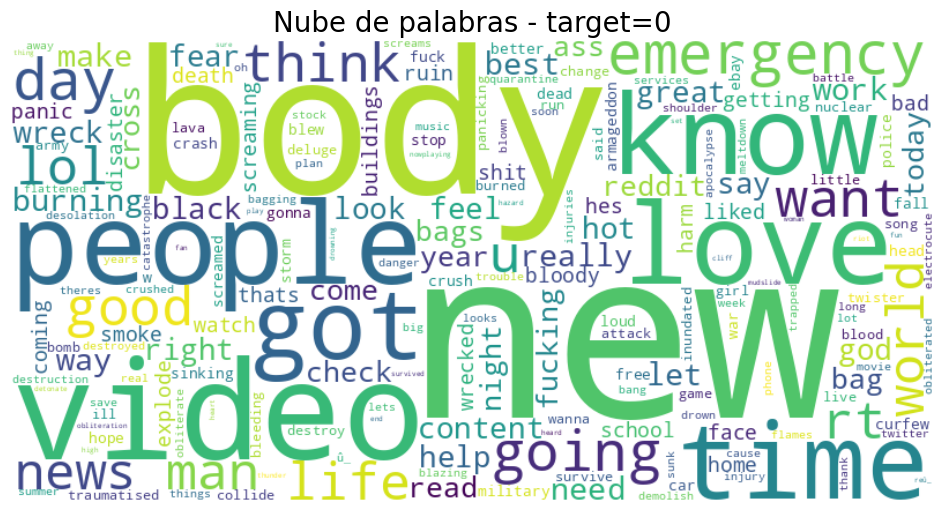

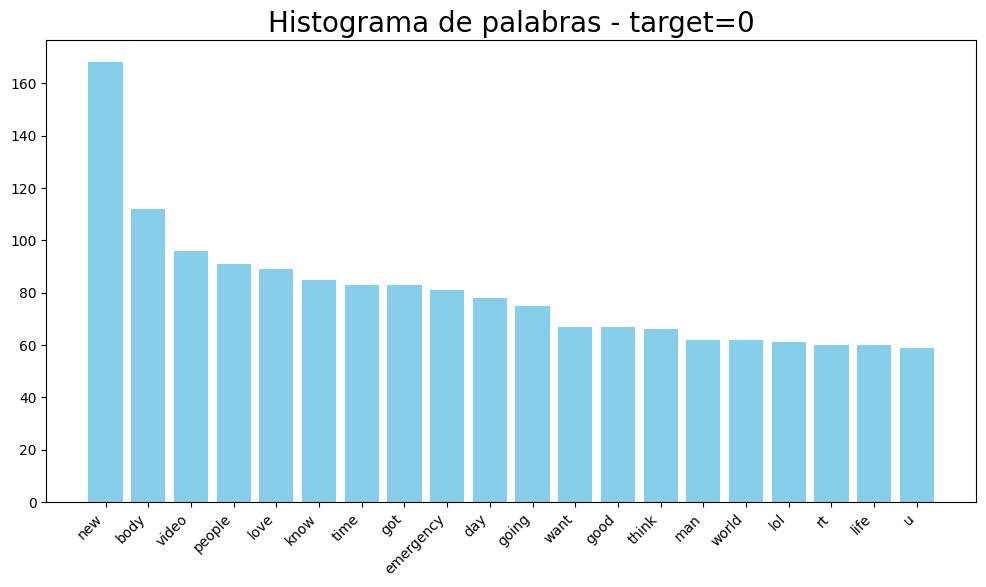

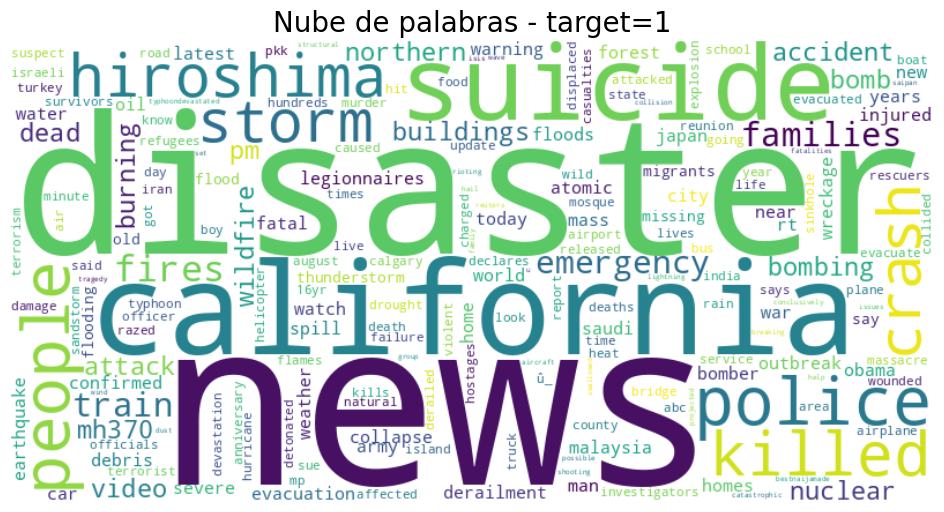

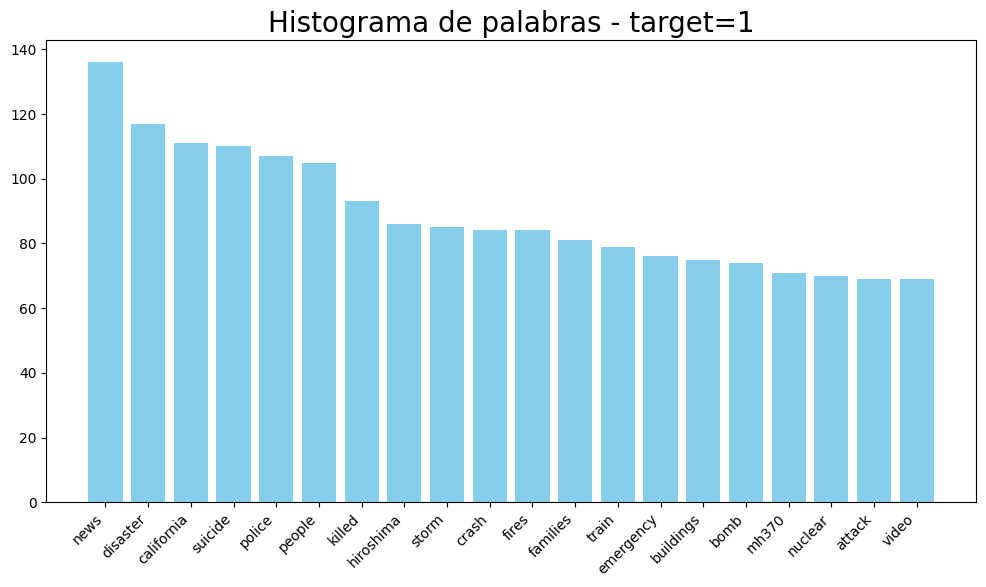

In [28]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Función para crear nube de palabras
def plot_wordcloud(counter, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(counter)
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

# Función para crear histograma de top N palabras
def plot_histogram(counter, title, top_n=20):
    most_common = counter.most_common(top_n)
    words, counts = zip(*most_common)
    plt.figure(figsize=(12,6))
    plt.bar(words, counts, color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title(title, fontsize=20)
    plt.show()

# Target = 0
plot_wordcloud(counter_0, "Nube de palabras - target=0")
plot_histogram(counter_0, "Histograma de palabras - target=0")

# Target = 1
plot_wordcloud(counter_1, "Nube de palabras - target=1")
plot_histogram(counter_1, "Histograma de palabras - target=1")



### Analisis

Podemos ver que las palabras que mas nos aparecen en el lado cuando es catalogado como desastre real son mas que todo palabras como noticia, desastre, policia, personas, muertos, tormenta, choque , familias , emergencias, y ataque, y tambien video.

Esto se debe a que de las anteriores hace mucha referencia a elementos parte de un desastre , y las noticias es debido  a que normalmente suelen aparecer desastres en las noticias , debido a esto es que aparece clasificada aqui. Con respecto a video se debe a que hoy en dia es mas facil de ver videos de eventos en vivo y dadas las circunstancias es normal que un desastre se muestre en este formato.


En cambio en las que no son desastre suelen aparecer palabras menos asociadas a estos fenomenos, tales como amor, mundo, cuerpo, bueno, vida. Pero tambien suelen aparecer palabras que aparecen tambien etiquetadas como desastre tales como emergencia, noticias y video. 

Esto se debe a que las palabras noticias y video no son siempre de cosas malas sino tambien de eventos que suelen ocurrir con normalidad o eventos en tendencia que no necesariamente tengan que ver con desastres. Y emergencia aparece en los 2 debido  a que no necesariamente pertenece a un contexto se desastres puede ser a cosas como tendencias y cosas que tengan que ver con la farandula que tampoco son desastres






## Analisis de Positividad

Usaremos textblop para poder determinar si una palabra es positiva o negativa

In [ ]:
import pandas as pd
from textblob import TextBlob

# ---------- 1) Clasificar palabra ----------
def clasificar_palabra(word):
    polarity = TextBlob(word).sentiment.polarity
    if polarity > 0:
        return "positiva"
    elif polarity < 0:
        return "negativa"
    else:
        return "neutra"

# ---------- 2) Analizar un tweet ----------
def analizar_tweet(text):
    palabras = str(text).split()  # tokenización simple para evitar problemas de NLTK
    
    positivas, negativas, neutras = [], [], []
    
    for w in palabras:
        clasificacion = clasificar_palabra(w)
        if clasificacion == "positiva":
            positivas.append(w)
        elif clasificacion == "negativa":
            negativas.append(w)
        else:
            neutras.append(w)
    
    # Clasificación del tweet
    if len(positivas) > len(negativas):
        sentimiento = "positivo"
    elif len(negativas) > len(positivas):
        sentimiento = "negativo"
    else:
        sentimiento = "neutral"
    
    # ---- Imprimir detalle del análisis ----
    print(f"\nTweet: {text}")
    print(f"  Positivas: {positivas}")
    print(f"  Negativas: {negativas}")
    print(f"  Neutras:   {neutras}")
    print(f"➡️  Clasificación del tweet: {sentimiento}")
    
    return {
        "positivas": positivas,
        "negativas": negativas,
        "neutras": neutras,
        "sentimiento": sentimiento
    }

resultados = train["text"].apply(analizar_tweet)

df_sentimientos = pd.DataFrame(list(resultados))

df_final = pd.concat([train["text"], df_sentimientos], axis=1)

print("\n📊 Dataset con clasificación:")
print(df_final.head())



Tweet: deeds reason earthquake allah forgive
  Positivas: []
  Negativas: []
  Neutras:   ['deeds', 'reason', 'earthquake', 'allah', 'forgive']
➡️  Clasificación del tweet: neutral

Tweet: forest near la ronge sask canada
  Positivas: ['near']
  Negativas: []
  Neutras:   ['forest', 'la', 'ronge', 'sask', 'canada']
➡️  Clasificación del tweet: positivo

Tweet: residents asked shelter place notified officers evacuation shelter place orders expected
  Positivas: []
  Negativas: ['expected']
  Neutras:   ['residents', 'asked', 'shelter', 'place', 'notified', 'officers', 'evacuation', 'shelter', 'place', 'orders']
➡️  Clasificación del tweet: negativo

Tweet:  people receive wildfires evacuation orders california
  Positivas: []
  Negativas: []
  Neutras:   ['people', 'receive', 'wildfires', 'evacuation', 'orders', 'california']
➡️  Clasificación del tweet: neutral

Tweet: got sent photo ruby alaska smoke wildfires pours school
  Positivas: []
  Negativas: []
  Neutras:   ['got', 'sent', 

In [34]:
df_final["score"] = df_final["positivas"].apply(len) - df_final["negativas"].apply(len)


Ahora mostraremos los tweets mas positivos y negativos

In [37]:
# Más positivos
print("Tweets más positivos:")
print(df_final.sort_values("score", ascending=False)[["text", "score", "sentimiento"]].head(10))

# Más negativos
print("\nTweets más negativos:")
print(df_final.sort_values("score")[["text", "score", "sentimiento"]].head(10))


Tweets más positivos:
                                                   text  score sentimiento
3382  batfanuk enjoyed today great fun emergency non...      5    positivo
3163  batfanuk enjoyed today great fun emergency non...      5    positivo
7299  great footage strong work san bernardino count...      4    positivo
4710  morning_joe reince presssec joe ur smart u run...      4    positivo
303   liked video minecraft night lucky block mod bo...      4    positivo
6992  check want twister tickets vip experience shan...      4    positivo
5522  okay cat quarantined bathroomits meowing reall...      4    positivo
7568  riddler best earlyexit primary presidential wa...      4    positivo
4811   laugh loud things man really lol big bang theory      4    positivo
7307  senfeinstein thanks sen feinstein hurry home c...      4    positivo

Tweets más negativos:
                                                   text  score sentimiento
6980  stop fucking saying ûïa ûnotherû sounds fuckin...